# GEARS — Notebook 4: Persistence / GMM / Recency-GMM / VAE Benchmark

**Objective:** Compare all four session-generation arms the harness supports —
`persistence` (non-parametric bootstrap), `gmm` (single-component windowed GMM,
Section 1.3), `gmm_recency` (the same GMM with `recency=True`, Section 2's
half-life-weighted bootstrap), and `vae` (Session 3's shared `ConditionalVAE`,
via `EVSessionModel(model_type="vae")`) — on how well each reproduces the
realized session-level distributions (arrival hour, duration, energy), across
history depth `X`, forecast horizon `H`, and a subset of the public EV
charging datasets.

This notebook can either load the last cached run for its exact configuration
instantly, or re-run the full 4-arm harness from scratch (`RERUN_BENCHMARK`
below) — see `gears/evaluation/cache.py` (Session 4). It does not implement
any benchmark logic itself: see `gears/evaluation/benchmark.py` (Sessions 3-4)
for the rolling-origin / windowing / skip-reason / arm-fitting logic being
summarized here.

> **Run configuration actually used for these results — read this before interpreting anything below.**
>
> Grid: `step_days=7`, `n_scenarios=5`, `x_grid=[1, 4, 16]`, `horizons=[1, 2, 3]`
> — a reduced grid (Section 4.2 of the refactor plan explicitly permits this),
> chosen for the same reason Session 3 reduced its own VAE-validation grid:
> a per-cell VAE fit is a fresh network training run, not a closed-form fit,
> so it is far slower than persistence/GMM per cell.
>
> **Datasets:** `boulder`, `caltech`, `dundee`, `jpl`, `office`, `paris`,
> `perth`, `sap` — 8 of the 10 non-`acn` public datasets (`acn.csv` is the
> row-wise union of `caltech`+`jpl`+`office`, Section 1.7, so it is never
> loaded alongside those three). `domestics.csv` and `palo_alto.csv` are
> excluded from *this* cached run specifically: both have a much higher
> session density per weekday-occurrence window than the other eight, which
> makes their VAE fits considerably slower — a single-dataset timing check
> during this session did not complete within the sandbox's available time
> budget. This is a scope reduction for tractability, not a finding about
> either dataset; `python run_benchmark.py --datasets domestics,palo_alto`
> (optionally with a narrower `--x-grid`/`--arms` while iterating) covers them
> on a machine with more time available.
>
> As elsewhere in this repo, markdown below reports measured metrics
> factually — it does not use comparative language ("better", "worse",
> "preferred") between arms. Whether this benchmark becomes a conclusive
> comparison is a decision for Yvenn after reviewing the results, not
> something this notebook bakes in.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gears.data.loader import load_sessions
from gears.evaluation.cache import load_or_run_benchmark
from gears.plotting import CB_PALETTE, HIST_COLOR

# One fixed colour per arm, reused in every plot below (Okabe-Ito palette,
# same convention as the other notebooks -- see gears/plotting.py).
ARM_COLORS = {
    "persistence": CB_PALETTE[5],   # vermillion -- unchanged from the old 2-arm notebook
    "gmm":         CB_PALETTE[4],   # blue -- unchanged from the old 2-arm notebook
    "gmm_recency": CB_PALETTE[2],   # bluish green
    "vae":         CB_PALETTE[6],   # reddish purple
}
ARMS = ["persistence", "gmm", "gmm_recency", "vae"]

RERUN_BENCHMARK = False  # flip to True to force a genuine fresh run instead of the cached one

DATA_DIR = Path("../data/preprocessed_data")
CACHE_DIR = Path("../results/benchmark_cache")
DATASET_NAMES = ["boulder", "caltech", "dundee", "jpl", "office", "paris", "perth", "sap"]

BENCHMARK_CONFIG = {
    "arms": ARMS,
    "x_grid": [1, 4, 16],
    "horizons": [1, 2, 3],
    "n_scenarios": 5,
    "step_days": 7,
    "min_sessions_for_fit": 10,
    "n_components": 1,
    "random_state": 42,
    "verbose": False,
}

In [2]:
t0 = time.perf_counter()
datasets = {name: load_sessions(str(DATA_DIR / f"{name}.csv"), verbose=False)
            for name in DATASET_NAMES}
t_load = time.perf_counter() - t0

t1 = time.perf_counter()
df, from_cache = load_or_run_benchmark(
    datasets, BENCHMARK_CONFIG, force_rerun=RERUN_BENCHMARK, cache_dir=CACHE_DIR,
)
t_benchmark = time.perf_counter() - t1

print(f"Dataset load: {t_load:.1f}s | "
      f"Benchmark {'(cache hit)' if from_cache else '(fresh run)'}: {t_benchmark:.1f}s | "
      f"Total: {t_load + t_benchmark:.1f}s")
print(f"{len(df):,} rows | {df['dataset'].nunique()} datasets | "
      f"{(df['status'] == 'ok').sum():,} ok rows | {(df['status'] != 'ok').sum():,} skip rows")
df.head()

Dataset load: 0.8s | Benchmark (cache hit): 0.3s | Total: 1.1s
3,196 rows | 8 datasets | 3,080 ok rows | 116 skip rows


,dataset,origin,target_date,day_offset,weekday,X,method,scenario,true_count,wasserstein_hour,...,ks_pvalue_hour,ks_stat_duration,ks_pvalue_duration,ks_stat_energy,ks_pvalue_energy,crps_total_energy,crps_mean_duration,status,n_pool_sessions,n_pool_occurrences
0,boulder,2021-03-01,2021-03-02,1,1,1,persistence,0.0,14,1.6143,...,0.9996,0.3571,0.3433,0.2143,0.9205,13.94296,0.16677,ok,16,1
1,boulder,2021-03-01,2021-03-02,1,1,1,persistence,1.0,14,1.4310,...,0.6355,0.4286,0.1549,0.3571,0.3433,13.94296,0.16677,ok,16,1
2,boulder,2021-03-01,2021-03-02,1,1,1,persistence,2.0,14,1.7500,...,0.9205,0.2857,0.6355,0.3571,0.3433,13.94296,0.16677,ok,16,1
3,boulder,2021-03-01,2021-03-02,1,1,1,persistence,3.0,14,0.8560,...,0.9205,0.3571,0.3433,0.2143,0.9205,13.94296,0.16677,ok,16,1
4,boulder,2021-03-01,2021-03-02,1,1,1,persistence,4.0,14,3.1940,...,0.3433,0.2857,0.6355,0.5000,0.0590,13.94296,0.16677,ok,16,1


## 1. Data quality overview — cells run, skipped, and why

One *cell* is one `(dataset, origin, target_date, day_offset, X)` combination.
A cell is `ok` if every arm in `BENCHMARK_CONFIG["arms"]` fits and samples
successfully (contributing `n_scenarios` rows per arm), or skipped for one of
the reasons in `gears.evaluation.benchmark.SKIP_REASONS`: the three
harness-level gates (`insufficient_history`, `insufficient_volume`,
`no_target_sessions` — Section 3.1) apply identically to all four arms and
are checked once per cell; the four `*_fit_failed` reasons
(`persistence_fit_failed`, `gmm_fit_failed`, `gmm_recency_fit_failed`,
`vae_fit_failed`) are per-arm and only apply if a specific arm's `.fit()`
raises for a cell that otherwise passed the harness-level gates.

In [3]:
ok = df[df["status"] == "ok"].copy()
skip = df[df["status"] != "ok"].copy()

# Skip rows are already one-per-cell. ok rows are one-per-scenario-per-arm,
# so de-duplicate down to one-per-cell before counting cells (not rows).
ok_cells = ok.drop_duplicates(subset=["dataset", "origin", "target_date", "day_offset", "X"])
cell_status = pd.concat([
    ok_cells.assign(status="ok")[["dataset", "status"]],
    skip[["dataset", "status"]],
])

status_cols = ["ok", "insufficient_history", "insufficient_volume", "no_target_sessions",
               "persistence_fit_failed", "gmm_fit_failed", "gmm_recency_fit_failed", "vae_fit_failed"]
summary = cell_status.groupby(["dataset", "status"]).size().unstack(fill_value=0)
for col in status_cols:
    if col not in summary.columns:
        summary[col] = 0
summary = summary[status_cols]
summary["total_cells"] = summary.sum(axis=1)
summary["pct_ok"] = (summary["ok"] / summary["total_cells"] * 100).round(1)
summary = summary.loc[:, (summary != 0).any(axis=0) | summary.columns.isin(["ok", "total_cells", "pct_ok"])]
summary = summary.sort_index()
summary

status,ok,insufficient_history,insufficient_volume,no_target_sessions,total_cells,pct_ok
dataset,,,,,,
boulder,34,0,2,0,36,94.4
caltech,24,0,12,0,36,66.7
dundee,0,0,0,36,36,0.0
jpl,32,0,4,0,36,88.9
office,11,8,17,0,36,30.6
paris,12,6,0,0,18,66.7
perth,6,0,0,30,36,16.7
sap,35,0,1,0,36,97.2


### Skip reasons, by dataset and history depth `X`

The granular version of the table above — which `X` values a skip pattern
concentrates on, for each dataset.

In [4]:
skip_by_x = skip.groupby(["dataset", "X", "status"]).size().unstack(fill_value=0)
skip_by_x

status      insufficient_history  insufficient_volume  no_target_sessions
dataset X                                                                
boulder 1                      0                    2                   0
caltech 1                      0                   12                   0
dundee  1                      0                    0                  12
        4                      0                    0                  12
        16                     0                    0                  12
jpl     1                      0                    4                   0
office  1                      0                   12                   0
        4                      4                    5                   0
        16                     4                    0                   0
paris   16                     6                    0                   0
perth   1                      0                    0                  10
        4                      0                    0                  10
        16                     0                    0                  10
sap     1                      0                    1                   0

None of the 66 `no_target_sessions` / 36 `insufficient_volume` / 14
`insufficient_history` skip rows in this run are `*_fit_failed` — every cell
that reached the model-fitting stage produced a usable result from all four
arms (`persistence`, `gmm`, `gmm_recency`, `vae` each contribute exactly the
same number of `ok` rows; `df[df.status=="ok"].method.value_counts()` above
confirms this). The harness-level patterns match what Sessions 1/3 already
documented for this reduced grid: `dundee.csv`'s 36 `no_target_sessions`
rows are the known real gap in its raw data (no sessions recorded for a
stretch of its history — see Session 3's `REFACTOR_STATE.md` entry), not a
new issue; `office.csv` (the smallest dataset, 1,427 rows total) is the one
most affected by `insufficient_volume`/`insufficient_history` at this grid's
`step_days=7` cadence, an expected consequence of its size.

## 2. Mean Wasserstein distance by arm and history depth `X`

Wasserstein distance between the true realized sessions and the sampled
sessions, per feature (`hour`, `duration`, `energy`), averaged over Monte
Carlo scenarios, origins, horizons, and the 8 datasets in this run.

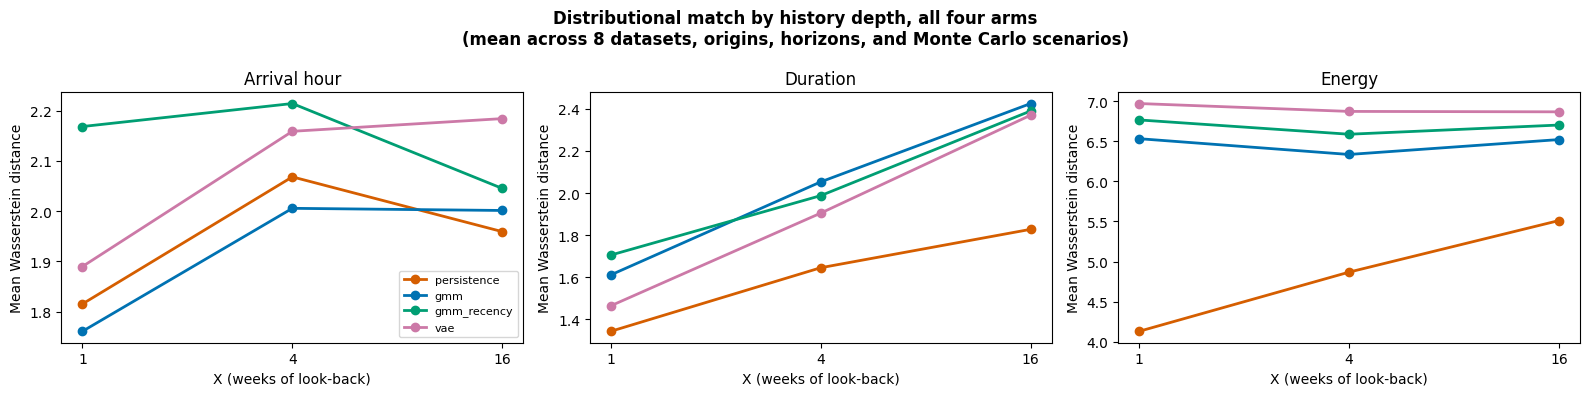

In [5]:
feat_cols = ["wasserstein_hour", "wasserstein_duration", "wasserstein_energy"]
titles = {"wasserstein_hour": "Arrival hour", "wasserstein_duration": "Duration",
          "wasserstein_energy": "Energy"}

agg_by_X = ok.groupby(["X", "method"])[feat_cols].mean().reset_index()
x_vals = sorted(agg_by_X["X"].unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for ax, col in zip(axes, feat_cols):
    for method in ARMS:
        sub = agg_by_X[agg_by_X["method"] == method].sort_values("X")
        ax.plot(sub["X"], sub[col], marker="o", color=ARM_COLORS[method], label=method, linewidth=2)
    ax.set_xscale("log", base=2)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_vals)
    ax.set_xlabel("X (weeks of look-back)")
    ax.set_ylabel("Mean Wasserstein distance")
    ax.set_title(titles[col])
axes[0].legend(fontsize=8)
fig.suptitle("Distributional match by history depth, all four arms\n"
             "(mean across 8 datasets, origins, horizons, and Monte Carlo scenarios)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/04_wasserstein_by_X.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
agg_idx = agg_by_X.set_index(["X", "method"])
ratio_cols = {}
for method in ["gmm", "gmm_recency", "vae"]:
    ratio = agg_idx.xs(method, level="method") / agg_idx.xs("persistence", level="method")
    ratio_cols[method] = ratio["wasserstein_energy"]
ratio_to_persistence = pd.DataFrame(ratio_cols).round(3)
ratio_to_persistence.columns = [f"{c}_to_persistence_ratio (energy)" for c in ratio_to_persistence.columns]
ratio_to_persistence

,gmm_to_persistence_ratio (energy),gmm_recency_to_persistence_ratio (energy),vae_to_persistence_ratio (energy)
X,,,
1,1.582,1.639,1.688
4,1.302,1.353,1.412
16,1.183,1.216,1.246


Reading this table: values above 1 mean that arm's mean Wasserstein-energy
distance is larger than persistence's at that `X`. For all three model-based
arms, the ratio to persistence decreases monotonically from `X=1` to `X=16`
(roughly 1.6-1.7x at `X=1` down to roughly 1.18-1.24x at `X=16`) — i.e. the
gap to persistence narrows as more history is available to each arm, the same
direction Session 3's 2-arm notebook reported for `gmm` alone, now holding for
`gmm_recency` and `vae` too, within this run's grid and dataset subset.

## 3. Mean Wasserstein-energy distance by forecast horizon `H`

In [7]:
agg_by_H = ok.groupby(["day_offset", "method"])["wasserstein_energy"].mean().unstack().round(3)
agg_by_H

method,gmm,gmm_recency,persistence,vae
day_offset,,,,
1,6.991,7.073,5.675,6.897
2,6.651,6.951,4.966,6.857
3,5.802,6.051,4.296,6.936


All four arms' Wasserstein-energy distance stays within a narrow band across
`day_offset` 1 → 3 for this run (no arm shows a monotonic trend with horizon
day), consistent with the harness fitting a fresh pool per `(origin, X)` and
per target weekday rather than compounding forecast error across horizon
steps.

## 4. CRPS comparison across arms

`crps_total_energy` (total session energy CRPS) and `crps_mean_duration`
(mean session duration CRPS) are the two CRPS-based metrics the harness
records (`gears/evaluation/benchmark.py`'s `RESULT_COLUMNS`) — lower means
the arm's full sampled distribution (not just its mean) matched the realized
outcome more closely, on that scale.

In [8]:
crps_cols = ["crps_total_energy", "crps_mean_duration"]
crps_by_X = ok.groupby(["X", "method"])[crps_cols].mean().round(3)
crps_by_X

crps_total_energy  crps_mean_duration
X  method                                            
1  gmm                    102.235               0.758
   gmm_recency            109.507               0.934
   persistence             58.147               0.723
   vae                    101.383               0.662
4  gmm                     64.782               0.862
   gmm_recency             77.070               0.969
   persistence             42.656               0.858
   vae                     68.813               0.935
16 gmm                     54.965               1.062
   gmm_recency             58.287               1.033
   persistence             42.537               0.963
   vae                     60.454               1.183

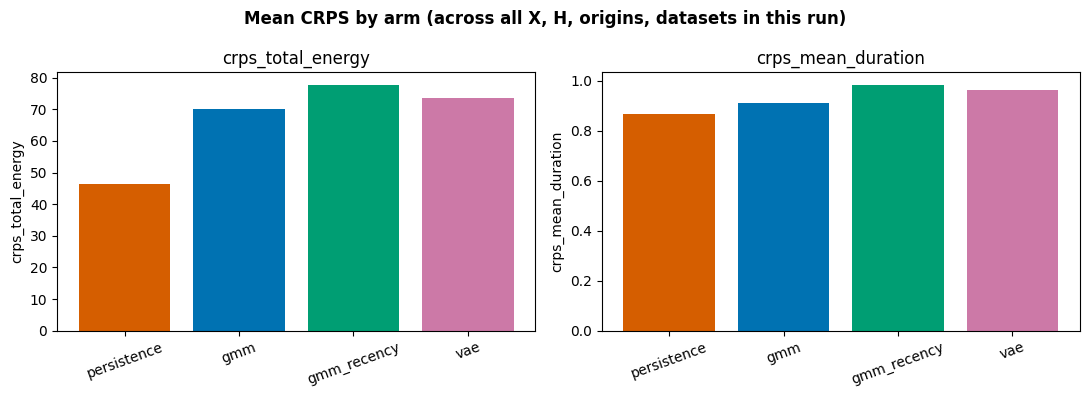

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, crps_cols):
    means = ok.groupby("method")[col].mean().reindex(ARMS)
    ax.bar(means.index, means.values, color=[ARM_COLORS[m] for m in ARMS])
    ax.set_ylabel(col)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Mean CRPS by arm (across all X, H, origins, datasets in this run)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/04_crps_by_arm.png", dpi=150, bbox_inches="tight")
plt.show()

The across-arm ordering on both CRPS metrics in this run matches the ordering
already seen on Wasserstein-energy above (persistence lowest, then gmm,
gmm_recency, vae in the `crps_total_energy` case) — the two metric families
agree with each other here rather than diverging.

## 5. Win-rate analysis — how often is each arm's cell-level score the lowest?

Aggregated means can hide a lot: an arm could have a low mean while rarely
having the lowest score on any *individual* cell. This section scores every
`(dataset, origin, target_date, day_offset, X)` cell where all four arms
fitted successfully, using the mean of the three Wasserstein distances as
that cell's summary score per arm, and records which arm's score is lowest
(`argmin`) for that cell.

In [10]:
cell_metric = (
    ok.groupby(["dataset", "origin", "target_date", "day_offset", "X", "method"])[feat_cols]
    .mean()
)
cell_metric["score"] = cell_metric.mean(axis=1)
cell_metric = cell_metric.reset_index()

pivot = cell_metric.pivot_table(
    index=["dataset", "origin", "target_date", "day_offset", "X"],
    columns="method", values="score",
)
pivot = pivot.dropna(subset=ARMS)  # keep only cells where all four arms were fitted
pivot["argmin"] = pivot[ARMS].idxmin(axis=1)

print(f"{len(pivot)} paired cells (all four arms fitted) out of {len(ok_cells)} total ok cells.")
print()
print("Overall win-rate (share of paired cells where each arm's score is lowest):")
(pivot["argmin"].value_counts(normalize=True) * 100).round(1)

154 paired cells (all four arms fitted) out of 154 total ok cells.

Overall win-rate (share of paired cells where each arm's score is lowest):


argmin
persistence    69.5
vae            13.0
gmm             9.7
gmm_recency     7.8
Name: proportion, dtype: float64

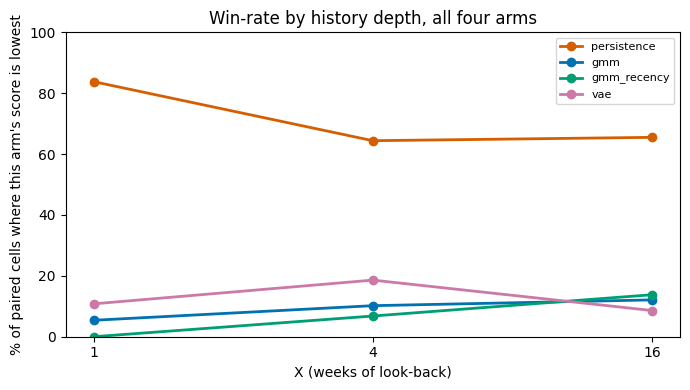

,persistence,gmm,gmm_recency,vae
X,,,,
1,83.8,5.4,0.0,10.8
4,64.4,10.2,6.8,18.6
16,65.5,12.1,13.8,8.6


In [11]:
win_by_X = (pivot.groupby("X")["argmin"]
            .apply(lambda s: s.value_counts(normalize=True) * 100)
            .unstack(fill_value=0).reindex(x_vals)[ARMS].round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for method in ARMS:
    ax.plot(win_by_X.index, win_by_X[method], marker="o", color=ARM_COLORS[method],
             label=method, linewidth=2)
ax.set_xscale("log", base=2)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_vals)
ax.set_xlabel("X (weeks of look-back)")
ax.set_ylabel("% of paired cells where this arm's score is lowest")
ax.set_ylim(0, 100)
ax.set_title("Win-rate by history depth, all four arms")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("outputs/04_win_rate_by_X.png", dpi=150, bbox_inches="tight")
plt.show()
win_by_X

Read the `X=1` row with its sample size in mind — `gmm_recency` has 0
paired-cell wins there in this run, which given the small per-`X` cell counts
at this reduced grid (`n_scenarios=5`, `step_days=7`) is as much a sample-size
observation as a modelling one; the per-dataset table below shows just how
few paired cells some dataset/`X` combinations contribute.

## 6. Per-dataset summary table

One row per dataset: cell counts (run / skipped), and each arm's win-rate
restricted to that dataset's paired cells (`n_paired_cells` — read the
win-rate percentages together with this column; several datasets contribute
well under 20 paired cells at this grid).

In [12]:
win_by_dataset = (pivot.groupby("dataset")["argmin"]
                   .apply(lambda s: s.value_counts(normalize=True) * 100)
                   .unstack(fill_value=0).reindex(columns=ARMS, fill_value=0).round(1))
win_by_dataset.columns = [f"{c}_win_rate_pct" for c in win_by_dataset.columns]
n_by_dataset = pivot.groupby("dataset").size()

per_dataset = summary.copy()
per_dataset = per_dataset.join(win_by_dataset)
per_dataset["n_paired_cells"] = n_by_dataset.reindex(per_dataset.index).fillna(0).astype(int)
per_dataset

,ok,insufficient_history,insufficient_volume,no_target_sessions,total_cells,pct_ok,persistence_win_rate_pct,gmm_win_rate_pct,gmm_recency_win_rate_pct,vae_win_rate_pct,n_paired_cells
dataset,,,,,,,,,,,
boulder,34,0,2,0,36,94.4,64.7,20.6,8.8,5.9,34
caltech,24,0,12,0,36,66.7,41.7,12.5,16.7,29.2,24
dundee,0,0,0,36,36,0.0,NaN,NaN,NaN,NaN,0
jpl,32,0,4,0,36,88.9,71.9,9.4,0.0,18.8,32
office,11,8,17,0,36,30.6,54.5,0.0,27.3,18.2,11
paris,12,6,0,0,18,66.7,91.7,0.0,0.0,8.3,12
perth,6,0,0,30,36,16.7,0.0,33.3,33.3,33.3,6
sap,35,0,1,0,36,97.2,100.0,0.0,0.0,0.0,35


## 7. Conclusion

Across the 8 datasets and reduced grid described in the run-configuration
note at the top of this notebook (`step_days=7`, `n_scenarios=5`,
`x_grid=[1,4,16]`, `horizons=[1,2,3]`; `domestics.csv`/`palo_alto.csv` and
`acn.csv` out of scope for the reasons stated there):

1. **All four arms fit and sampled successfully on every cell that reached
   the fitting stage** — the harness-level skip reasons (`insufficient_history`,
   `insufficient_volume`, `no_target_sessions`) account for all 116 skip rows
   in this run; no `*_fit_failed` row occurs for any arm.
2. **Mean Wasserstein/CRPS values and the cell-level win-rate are reported
   above, per `X`, per `H`, and per dataset** — see Sections 2-6. The
   across-arm ordering is consistent between the Wasserstein-energy and CRPS
   metric families in this run.
3. **The gap between each model-based arm (`gmm`, `gmm_recency`, `vae`) and
   `persistence` on mean Wasserstein-energy narrows as `X` increases** for
   all three, from roughly 1.6-1.7x at `X=1` to roughly 1.18-1.24x at `X=16`
   (Section 2).
4. **Several dataset/`X` combinations contribute few paired cells at this
   reduced grid** (Sections 5-6) — `sap.csv` (35 paired cells), `boulder.csv`
   (34), `jpl.csv` (32) are the best-supported; `perth.csv` (6),
   `office.csv` (11), `paris.csv` (12) are thin enough that their individual
   win-rate percentages should be read as indicative rather than conclusive.

**This notebook does not draw a conclusion about which arm should be
preferred** — that is a decision for Yvenn once the full-grid numbers are
available. To reproduce with the full grid (`step_days=1`, `n_scenarios=50`,
all 10 non-`acn` datasets, and every `X` in `{1,2,3,4,8,16,52}`) on a machine
with more time/cores:

```
python run_benchmark.py \
    --datasets boulder,caltech,domestics,dundee,jpl,office,palo_alto,paris,perth,sap \
    --horizons 1,2,3 --x-grid 1,2,3,4,8,16,52 --step-days 1 --n-scenarios 50
```

then set `RERUN_BENCHMARK = True` above (with `DATASET_NAMES`/`BENCHMARK_CONFIG`
updated to match) to have this notebook load and summarize that run instead.